
### Q1
**Build a Logistic Regression classifier on the Iris dataset. Print confusion matrix and full classification report.**

Follow-up Questions:

1. What does train_test_split's stratify parameter do and why did you use it?
2. What does solver='lbfgs' mean and what other solvers exist?
3. Change the classification threshold from 0.5 to 0.3. What changes in predictions?
4. What does model.predict_proba() return vs model.predict()?
5. Add L2 regularisation — which parameter controls it and what default does sklearn use?


In [1]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
X = iris.drop(columns=["species"])
y = iris.species

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
log_reg = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)

log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


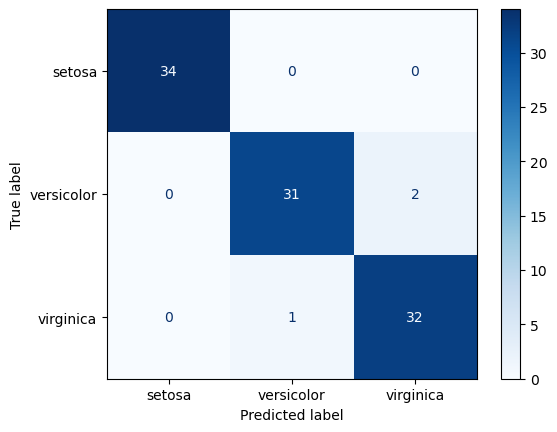

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        34
  versicolor       0.97      0.94      0.95        33
   virginica       0.94      0.97      0.96        33

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [4]:
y_train_pred = log_reg.predict(X_train)

cm = confusion_matrix(y_train, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["setosa", "versicolor", "virginica"]).plot(cmap="Blues")
plt.show()

print(classification_report(y_train, y_train_pred))

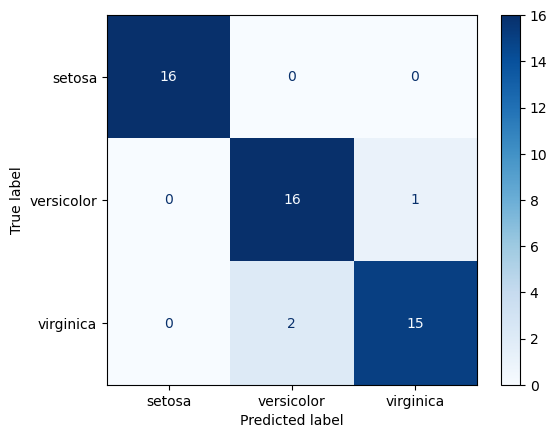

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        16
  versicolor       0.89      0.94      0.91        17
   virginica       0.94      0.88      0.91        17

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



In [5]:
y_test_pred = log_reg.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["setosa", "versicolor", "virginica"]
).plot(cmap="Blues")
plt.show()

print(classification_report(y_test, y_test_pred))

In [13]:
import numpy as np

probs = log_reg.predict_proba(X_test)

y_pred_custom = []

thresholds = [1.0, 0.4, 0.5]

classes = log_reg.classes_

for prob in probs:
    chosen = None
    if prob.max() < thresholds[np.argmax(prob)]:
        chosen = "unknown"
    else:
        chosen = classes[np.argmax(prob)]

    y_pred_custom.append(chosen)

y_pred_custom

['versicolor',
 'versicolor',
 'unknown',
 'versicolor',
 'virginica',
 'versicolor',
 'versicolor',
 'unknown',
 'versicolor',
 'versicolor',
 'unknown',
 'unknown',
 'unknown',
 'unknown',
 'unknown',
 'virginica',
 'virginica',
 'versicolor',
 'virginica',
 'versicolor',
 'virginica',
 'versicolor',
 'unknown',
 'virginica',
 'unknown',
 'virginica',
 'virginica',
 'unknown',
 'unknown',
 'virginica',
 'virginica',
 'virginica',
 'unknown',
 'versicolor',
 'unknown',
 'unknown',
 'virginica',
 'versicolor',
 'virginica',
 'versicolor',
 'versicolor',
 'versicolor',
 'unknown',
 'unknown',
 'virginica',
 'versicolor',
 'virginica',
 'versicolor',
 'versicolor',
 'virginica']

## KNN
Implement KNN on the Iris dataset. Try K values from 1 to 20 and plot accuracy vs K to find the elbow.


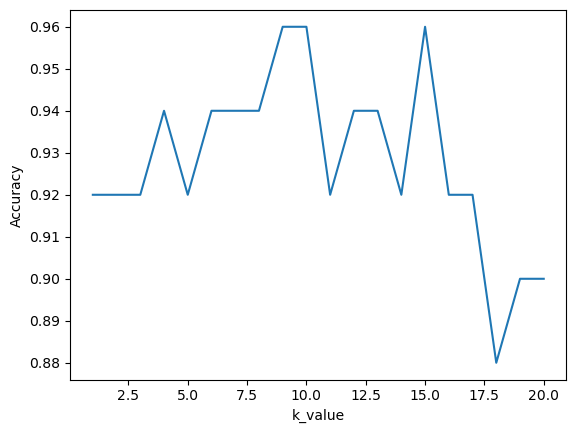

np.int64(9)

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib. pyplot as plt
import numpy as np

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

accuracies = []

for k in range(1,21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(range(1,21), accuracies)
plt.xlabel("k_value")
plt.ylabel("Accuracy")
plt.show()

best_k = np.argmax(accuracies) + 1
best_k


### Euclidean distance / Manhattan Distance

In [19]:
import math

def euc_distance(p1, p2):
    distance = 0

    for i in range(len(p1)):
        distance += (p1[i] - p2[i]) ** 2

    return math.sqrt(distance)


def man_distance(p1, p2):
    distance = 0

    for i in range(len(p1)):
        distance += abs(p1[i] - p2[i])

    return distance


p1 = np.array([2, 3])
p2 = np.array([5, 7])

print(euc_distance(p1, p2))
print(man_distance(p1, p2))

5.0
7


## Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


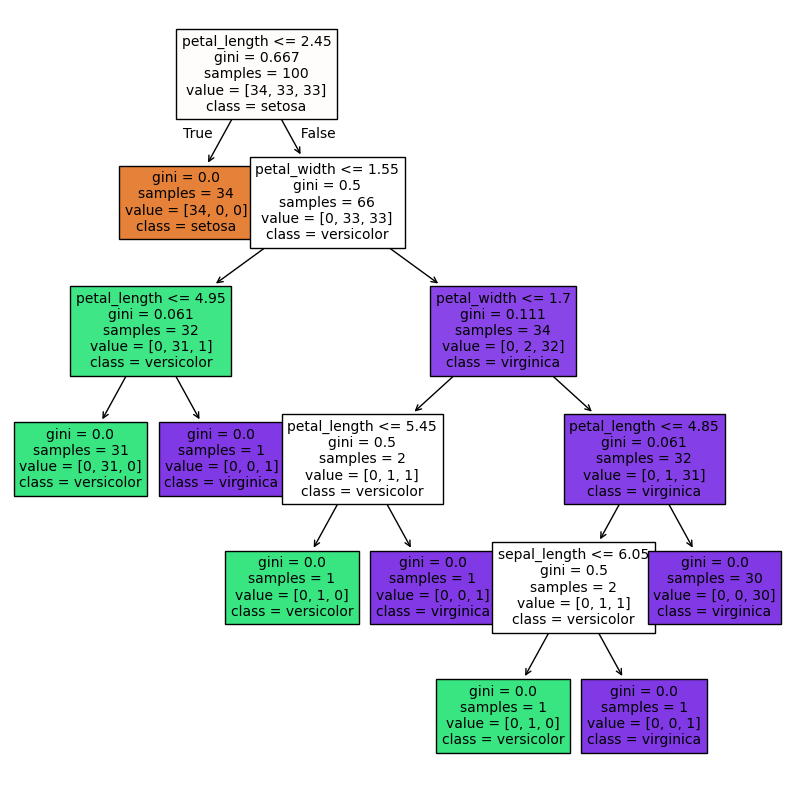

In [35]:
plt.figure(figsize=(10,10))
plot_tree(tree_clf, feature_names=X_train.columns, filled=True, fontsize=10, class_names=tree_clf.classes_)
plt.show()

In [36]:
importances = tree_clf.feature_importances_

for name, score in zip(X_train.columns, importances):
    print(name, score)

sepal_length 0.015001500150015
sepal_width 0.0
petal_length 0.5630813081308133
petal_width 0.42191719171917186


In [ ]:
f